# Tutorial 06



In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import torch
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import PIL
import requests

# Download the Dataset
We are using cats vs. dogs dataset used in Tutorial 01. Dataset can be downloaded from https://www.microsoft.com/en-us/download/details.aspx?id=54765

**Data**: Labeled images of dogs and cats.  
We want to learn a **classifier**: A function that returns a label (here: `cat`/`dog`) for images

In [1]:
from tqdm.notebook import tqdm
import numpy as np
import torch
import PIL
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("We are using {}".format(device))

We are using cuda


In [3]:
from torchvision.datasets import ImageFolder
from torchvision.transforms import Resize, ToTensor, Normalize, Compose
root_dir = 'PetImages'

target_size = (32, 32)
transforms = Compose([Resize(target_size), # Resizes image
                    ToTensor(),           # Converts to Tensor, scales to [0, 1] float (from [0, 255] int)
                    Normalize(mean=(0.5, 0.5, 0.5,), std=(0.5, 0.5, 0.5)), # scales to [-1.0, 1.0]
                    ])
corrupted_files = ["PetImages/Cat/666.jpg", "PetImages/Dog/11702.jpg"]
dataset_ = ImageFolder(
    root_dir, 
    transform=Resize((40,40)), 
    is_valid_file=lambda x: x.endswith("jpg") and x not in corrupted_files)

In [4]:
print(len(dataset_))

24998


0


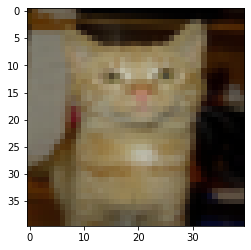

In [5]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.imshow(dataset_[101][0])
print(dataset_[101][1])

In [15]:
class RAMDatasetWrapper(torch.utils.data.Dataset):
    def __init__(self, dataset, transform=None):
        data = []
        for sample in tqdm(dataset):
            data.append(sample)
        self.n = len(data)
        self.data = data
        self.transform = transform
        
    def __getitem__(self, ind):
        if self.transform is not None:
            return self.transform(self.data[ind][0]), self.data[ind][1]
        else:
            return self.data[ind]
    
    def set_tranform(self, transform):
        self.transform = transform
    
    def __len__(self):
        return self.n

In [16]:
dataset = RAMDatasetWrapper(dataset_, transform=transforms)

  0%|          | 0/24998 [00:00<?, ?it/s]

/home/hc21r512/.conda/envs/genrep_env/lib/python3.7/site-packages/PIL/TiffImagePlugin.py:845: UserWarning: Truncated File Read
  warnings.warn(str(msg))


In [54]:
train_set, val_set = torch.utils.data.random_split(dataset, [22000, 2998])

In [56]:
import torch.nn as nn
class MLPModel(nn.Module):
    
    def __init__(self, input_dim, hidden_dim):
        super(MLPModel, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 2)
        )
    
    def forward(self, input):
        input = input.view(input.size(0), -1)
        return self.layers(input)

In [57]:
import numpy as np
def train_epoch(model, train_dataloader, optimizer, loss_fn):
    losses = []
    correct_predictions = 0
    # Iterate mini batches over training dataset
    for images, labels in tqdm(train_dataloader):
        images = images.to(device)
        labels = labels.to(device)
        # Run predictions
        output = model(images)
        # Set gradients to zero
        optimizer.zero_grad()
        # Compute loss
        loss = loss_fn(output, labels)
        # Backpropagate (compute gradients)
        loss.backward()
        # Make an optimization step (update parameters)
        optimizer.step()
        # Log metrics
        losses.append(loss.item())
        predicted_labels = output.argmax(dim=1)
        correct_predictions += (predicted_labels == labels).sum().item()
    accuracy = 100.0 * correct_predictions / len(train_dataloader.dataset)
    # Return loss values for each iteration and accuracy
    mean_loss = np.array(losses).mean()
    return mean_loss, accuracy


In [58]:
def evaluate(model, dataloader, loss_fn):
    losses = []
    correct_predictions = 0
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            # Run predictions
            output = model(images)
            # Compute loss
            loss = loss_fn(output, labels)
            # Save metrics
            predicted_labels = output.argmax(dim=1)
            correct_predictions += (predicted_labels == labels).sum().item()
            losses.append(loss.item())
    mean_loss = np.array(losses).mean()
    accuracy = 100.0 * correct_predictions / len(dataloader.dataset)
    # Return mean loss and accuracy
    return mean_loss, accuracy


In [59]:
def plot(train_losses, val_losses, train_accuracies, val_accuracies, title):
    plt.figure()
    plt.plot(np.arange(len(train_losses)), train_losses)
    plt.plot(np.arange(len(val_losses)), val_losses)
    plt.legend(['train_loss', 'val_loss'])
    plt.xlabel('epoch')
    plt.ylabel('loss value')
    plt.title('{}: Train/val loss'.format(title));

    plt.figure()
    plt.plot(np.arange(len(train_accuracies)), train_accuracies)
    plt.plot(np.arange(len(val_accuracies)), val_accuracies)
    plt.legend(['train_acc', 'val_acc'])
    plt.xlabel('epoch')
    plt.ylabel('accuracy')
    plt.title('{}: Train/val accuracy'.format(title));

In [60]:
from copy import deepcopy

def train_early_stopping(model, train_dataloader, val_dataloader, optimizer, n_epochs, loss_function):
    # We will monitor loss functions as the training progresses
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    ### EARLY STOPPING INITIALIZATION
    best_val_loss = np.inf
    best_model = None
    patience = 5 # if no improvement after 5 epochs, stop training
    counter = 0
    ###

    for epoch in range(n_epochs):
        model.train()
        train_loss, train_accuracy = train_epoch(model, train_dataloader, optimizer, loss_fn)
        model.eval()
        val_loss, val_accuracy = evaluate(model, val_dataloader, loss_fn)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_accuracy)
        val_accuracies.append(val_accuracy)
        print('Epoch {}/{}: train_loss: {:.4f}, train_accuracy: {:.4f}, val_loss: {:.4f}, val_accuracy: {:.4f}'.format(epoch+1, n_epochs,
                                                                                                      train_losses[-1],
                                                                                                      train_accuracies[-1],
                                                                                                      val_losses[-1],
                                                                                                      val_accuracies[-1]))
    
        ### EARLY STOPPING CODE
        if val_loss < best_val_loss: # If validation loss improved, save the model and reset the counter
            best_val_loss = val_loss
            best_model = deepcopy(model)
            counter = 0
        else: # If validation loss not improved, increase the counter
            counter += 1
        if counter == patience: # If no improvement for some number of epochs, stop training
            print('No improvement for {} epochs; training stopped.'.format(patience))
            break
    # Copy best model parameters to model
    for param1, param2 in zip(model.parameters(), best_model.parameters()):
        param1.data = param2.data
    ###
    return train_losses, val_losses, train_accuracies, val_accuracies

### Batch size effect

In [61]:
model = MLPModel(32*32*3, 64)
model = model.to(device)
learning_rate = 0.1
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
n_epochs = 15
loss_fn = nn.CrossEntropyLoss()

batch_size = 8
train_dataloader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=2)
val_dataloader = DataLoader(val_set, batch_size=batch_size, shuffle=False, num_workers=2)


In [62]:
train_losses_es, val_losses_es, train_acc_es, val_acc_es = train_early_stopping(model, train_dataloader, val_dataloader, optimizer, n_epochs, loss_fn)

  0%|          | 0/2750 [00:00<?, ?it/s]

Epoch 1/15: train_loss: 0.6593, train_accuracy: 60.0273, val_loss: 0.6335, val_accuracy: 63.5090


  0%|          | 0/2750 [00:00<?, ?it/s]

Epoch 2/15: train_loss: 0.6322, train_accuracy: 63.9636, val_loss: 0.6401, val_accuracy: 64.6431


  0%|          | 0/2750 [00:00<?, ?it/s]

...

Epoch 11/15: train_loss: 0.5362, train_accuracy: 72.3091, val_loss: 0.6436, val_accuracy: 64.8099


  0%|          | 0/2750 [00:00<?, ?it/s]

Epoch 12/15: train_loss: 0.5291, train_accuracy: 73.3000, val_loss: 0.6536, val_accuracy: 62.7085


  0%|          | 0/2750 [00:00<?, ?it/s]

Epoch 13/15: train_loss: 0.5240, train_accuracy: 73.6000, val_loss: 0.6554, val_accuracy: 63.5090
No improvement for 5 epochs; training stopped.


In [32]:
#plot(train_losses_es, val_losses_es, train_acc_es, val_acc_es, title='Early Stopping')

In [63]:
# Evaluate on best model
val_loss_early_stopping, val_accuracy_early_stopping = evaluate(model, val_dataloader, loss_fn)
print('Early stopping. Validation loss: {:.4f}, validation accuracy: {:.4f}'.format(val_loss_early_stopping, val_accuracy_early_stopping))

Early stopping. Validation loss: 0.6141, validation accuracy: 65.2769


In [64]:
model = MLPModel(32*32*3, 64)
model = model.to(device)
learning_rate = 0.1
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
n_epochs = 15
loss_fn = nn.CrossEntropyLoss()

batch_size = 64
train_dataloader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=2)
val_dataloader = DataLoader(val_set, batch_size=batch_size, shuffle=False, num_workers=2)
train_losses_es, val_losses_es, train_acc_es, val_acc_es = train_early_stopping(model, train_dataloader, val_dataloader, optimizer, n_epochs, loss_fn)

  0%|          | 0/344 [00:00<?, ?it/s]

Epoch 1/15: train_loss: 0.6629, train_accuracy: 59.5864, val_loss: 0.6337, val_accuracy: 63.6424


  0%|          | 0/344 [00:00<?, ?it/s]

Epoch 2/15: train_loss: 0.6262, train_accuracy: 64.0227, val_loss: 0.6194, val_accuracy: 64.8099


  0%|          | 0/344 [00:00<?, ?it/s]

...

Epoch 6/15: train_loss: 0.5679, train_accuracy: 70.0727, val_loss: 0.6407, val_accuracy: 63.7759


  0%|          | 0/344 [00:00<?, ?it/s]

Epoch 7/15: train_loss: 0.5563, train_accuracy: 71.2136, val_loss: 0.6434, val_accuracy: 63.0420


  0%|          | 0/344 [00:00<?, ?it/s]

Epoch 8/15: train_loss: 0.5453, train_accuracy: 71.6227, val_loss: 0.6228, val_accuracy: 65.5103
No improvement for 5 epochs; training stopped.


In [65]:
# Evaluate on best model
val_loss_early_stopping, val_accuracy_early_stopping = evaluate(model, val_dataloader, loss_fn)
print('Early stopping. Validation loss: {:.4f}, validation accuracy: {:.4f}'.format(val_loss_early_stopping, val_accuracy_early_stopping))

Early stopping. Validation loss: 0.6165, validation accuracy: 65.0100


# Batch normalization

In [66]:
import torch.nn as nn
    
class MLP_with_bn_Model(nn.Module):
    
    def __init__(self, input_dim, hidden_dim):
        super(MLP_with_bn_Model, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.BatchNorm1d(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.BatchNorm1d(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.BatchNorm1d(hidden_dim),
            nn.Linear(hidden_dim, 2)
        )
    
    def forward(self, input):
        input = input.view(input.size(0), -1)
        return self.layers(input)

In [67]:
model = MLP_with_bn_Model(32*32*3, 64)
model = model.to(device)
learning_rate = 0.1
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
n_epochs = 15
loss_fn = nn.CrossEntropyLoss()

batch_size = 64
train_dataloader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=2)
val_dataloader = DataLoader(val_set, batch_size=batch_size, shuffle=False, num_workers=2)
train_losses_es, val_losses_es, train_acc_es, val_acc_es = train_early_stopping(model, train_dataloader, val_dataloader, optimizer, n_epochs, loss_fn)

  0%|          | 0/344 [00:00<?, ?it/s]

Epoch 1/15: train_loss: 0.6638, train_accuracy: 60.6636, val_loss: 0.6391, val_accuracy: 63.0420


  0%|          | 0/344 [00:00<?, ?it/s]

Epoch 2/15: train_loss: 0.6294, train_accuracy: 64.2591, val_loss: 0.6224, val_accuracy: 64.4763


  0%|          | 0/344 [00:00<?, ?it/s]

...

Epoch 9/15: train_loss: 0.5376, train_accuracy: 72.5182, val_loss: 0.6223, val_accuracy: 65.4770


  0%|          | 0/344 [00:00<?, ?it/s]

Epoch 10/15: train_loss: 0.5191, train_accuracy: 73.6455, val_loss: 0.7040, val_accuracy: 62.9086


  0%|          | 0/344 [00:00<?, ?it/s]

Epoch 11/15: train_loss: 0.5106, train_accuracy: 74.2500, val_loss: 0.6314, val_accuracy: 64.8766
No improvement for 5 epochs; training stopped.


In [68]:
# Evaluate on best model
val_loss_early_stopping, val_accuracy_early_stopping = evaluate(model, val_dataloader, loss_fn)
print('Early stopping. Validation loss: {:.4f}, validation accuracy: {:.4f}'.format(val_loss_early_stopping, val_accuracy_early_stopping))

Early stopping. Validation loss: 0.6170, validation accuracy: 64.8099


# Scheduling


In [69]:
from copy import deepcopy

def train_early_stopping(model, train_dataloader, val_dataloader, optimizer, scheduler,  n_epochs, loss_function):
    # We will monitor loss functions as the training progresses
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    ### EARLY STOPPING INITIALIZATION
    best_val_loss = np.inf
    best_model = None
    patience = 5 # if no improvement after 5 epochs, stop training
    counter = 0
    ###

    for epoch in range(n_epochs):
        model.train()
        train_loss, train_accuracy = train_epoch(model, train_dataloader, optimizer, loss_fn)
        scheduler.step()
        model.eval()
        val_loss, val_accuracy = evaluate(model, val_dataloader, loss_fn)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accuracies.append(train_accuracy)
        val_accuracies.append(val_accuracy)
        print('Epoch {}/{}: train_loss: {:.4f}, train_accuracy: {:.4f}, val_loss: {:.4f}, val_accuracy: {:.4f}'.format(epoch+1, n_epochs,
                                                                                                      train_losses[-1],
                                                                                                      train_accuracies[-1],
                                                                                                      val_losses[-1],
                                                                                                      val_accuracies[-1]))
    
        ### EARLY STOPPING CODE
        if val_loss < best_val_loss: # If validation loss improved, save the model and reset the counter
            best_val_loss = val_loss
            best_model = deepcopy(model)
            counter = 0
        else: # If validation loss not improved, increase the counter
            counter += 1
        if counter == patience: # If no improvement for some number of epochs, stop training
            print('No improvement for {} epochs; training stopped.'.format(patience))
            break
    # Copy best model parameters to model
    for param1, param2 in zip(model.parameters(), best_model.parameters()):
        param1.data = param2.data
    ###
    return train_losses, val_losses, train_accuracies, val_accuracies

In [70]:
model = MLPModel(32*32*3, 64)
model = model.to(device)
learning_rate = 0.1
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
from torch.optim.lr_scheduler import StepLR


# Assuming optimizer uses lr = 0.1 for all groups
# lr = 0.1    if epoch < 5
# lr = 0.01    if 5 <= epoch < 10
# lr = 0.001   if 10 <= epoch < 15
# ...
scheduler = StepLR(optimizer, step_size=5, gamma=0.1)

n_epochs = 15
loss_fn = nn.CrossEntropyLoss()

batch_size = 64
train_dataloader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=2)
val_dataloader = DataLoader(val_set, batch_size=batch_size, shuffle=False, num_workers=2)


In [71]:
train_losses_es, val_losses_es, train_acc_es, val_acc_es = train_early_stopping(model, train_dataloader, val_dataloader, optimizer,scheduler, n_epochs, loss_fn)

  0%|          | 0/344 [00:00<?, ?it/s]

Epoch 1/15: train_loss: 0.6619, train_accuracy: 60.0045, val_loss: 0.6370, val_accuracy: 64.1761


  0%|          | 0/344 [00:00<?, ?it/s]

Epoch 2/15: train_loss: 0.6242, train_accuracy: 64.6636, val_loss: 0.6263, val_accuracy: 64.4096


  0%|          | 0/344 [00:00<?, ?it/s]

...

Epoch 11/15: train_loss: 0.5009, train_accuracy: 75.6773, val_loss: 0.6129, val_accuracy: 67.4116


  0%|          | 0/344 [00:00<?, ?it/s]

Epoch 12/15: train_loss: 0.4993, train_accuracy: 75.8455, val_loss: 0.6136, val_accuracy: 67.4450


  0%|          | 0/344 [00:00<?, ?it/s]

Epoch 13/15: train_loss: 0.4982, train_accuracy: 75.8909, val_loss: 0.6139, val_accuracy: 67.6785
No improvement for 5 epochs; training stopped.


In [73]:
# Evaluate on best model
val_loss_early_stopping, val_accuracy_early_stopping = evaluate(model, val_dataloader, loss_fn)
print('Early stopping. Validation loss: {:.4f}, validation accuracy: {:.4f}'.format(val_loss_early_stopping, val_accuracy_early_stopping))

Early stopping. Validation loss: 0.6059, validation accuracy: 67.6451
